**EDA**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed_data.csv')

**Basic Stats**

In [33]:
df.describe()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,0.556900,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180568
std,5773.647028,3.75489,0.569718,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.081068
min,1.000000,17.00000,0.000000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,4.076250
25%,5000.750000,20.00000,0.000000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,1.000000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,1.000000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,2.000000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,96.406250


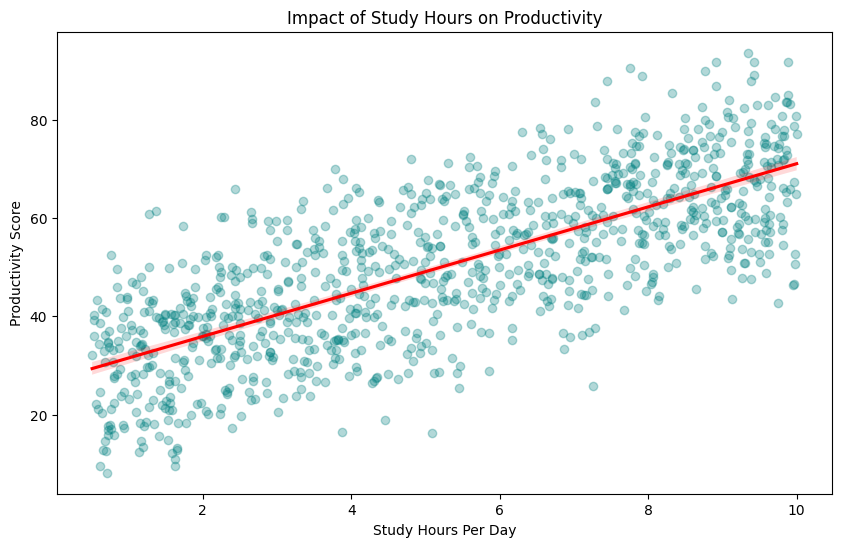

In [34]:
# 1. Study Hours vs Productivity (Trend Çizgili Saçılım Grafiği)
plt.figure(figsize=(10, 6))
sns.regplot(data=df.sample(1000), x='study_hours_per_day', y='productivity_score',
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Impact of Study Hours on Productivity')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Productivity Score')
plt.show()

**Productivity Score Distribution**

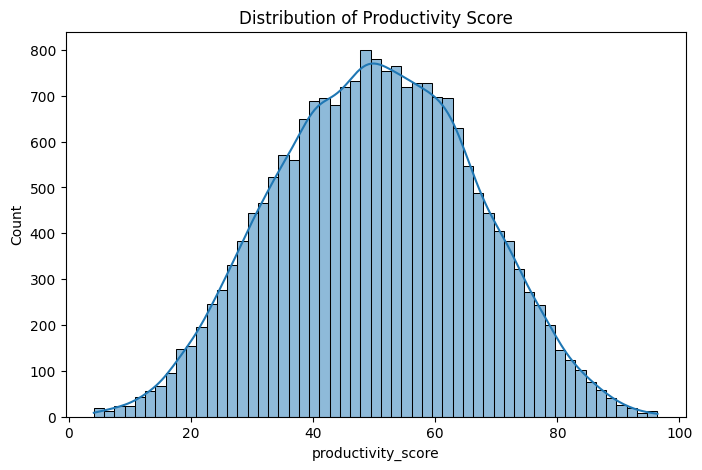

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['productivity_score'], kde=True)
plt.title("Distribution of Productivity Score")
plt.show()

**Correlation Heatmap**

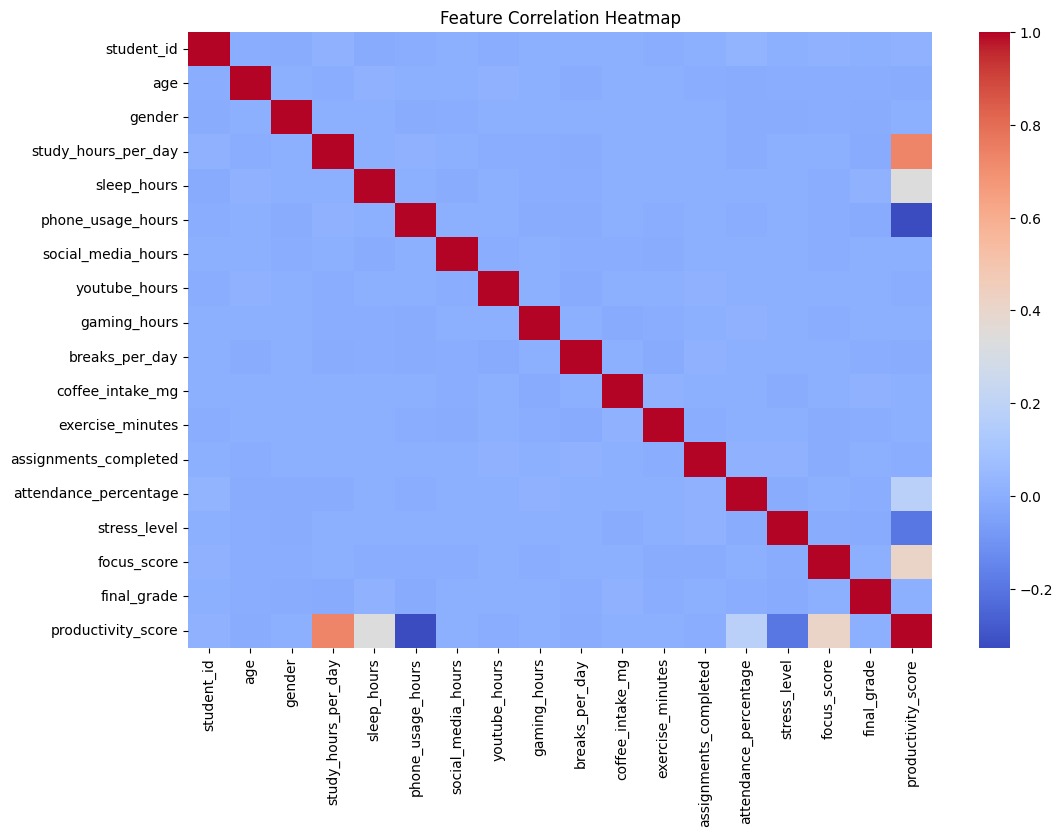

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**Productivity vs Study Hours**

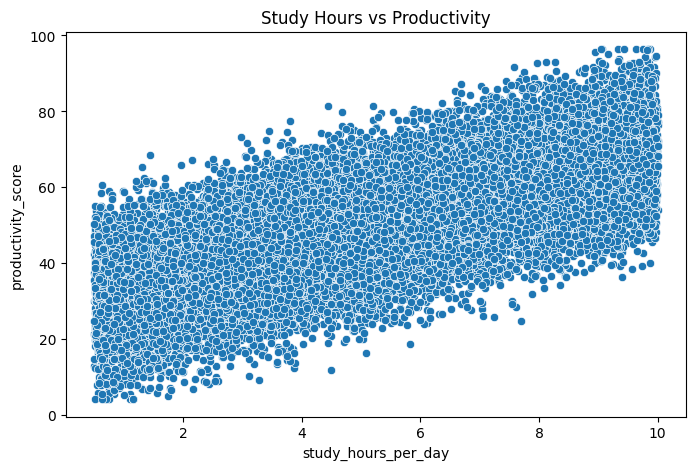

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['study_hours_per_day'],
    y=df['productivity_score']
)
plt.title("Study Hours vs Productivity")
plt.show()

**Productivity vs Phone Usage**

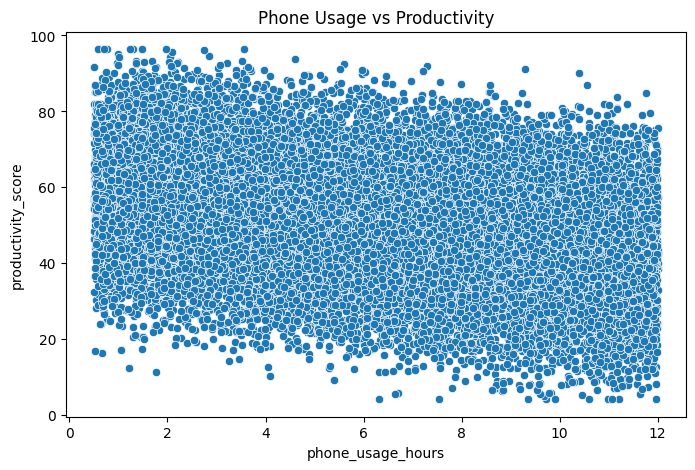

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['phone_usage_hours'],
    y=df['productivity_score']
)
plt.title("Phone Usage vs Productivity")
plt.show()

**Productivity vs Sleep**

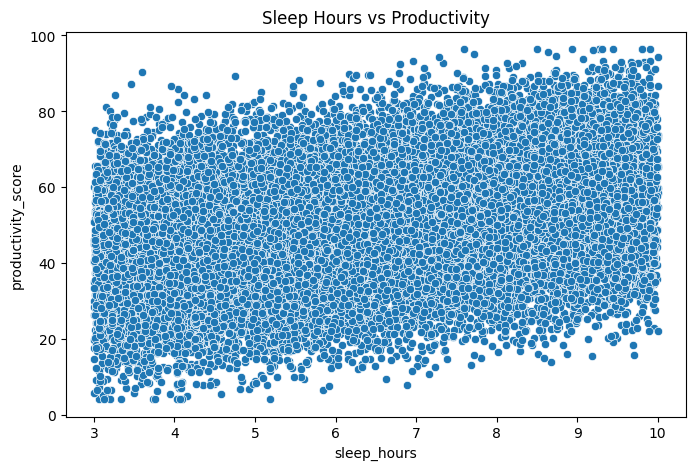

In [39]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['sleep_hours'],
    y=df['productivity_score']
)
plt.title("Sleep Hours vs Productivity")
plt.show()

**Productivity vs Stress**

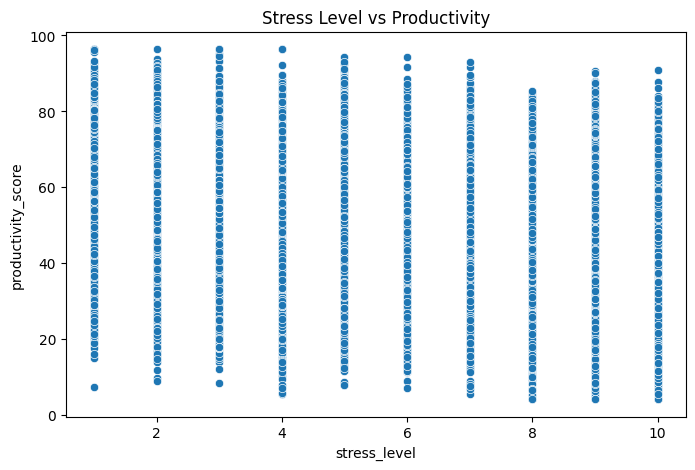

In [40]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['stress_level'],
    y=df['productivity_score']
)
plt.title("Stress Level vs Productivity")
plt.show()

**Boxplot (Outliers)**

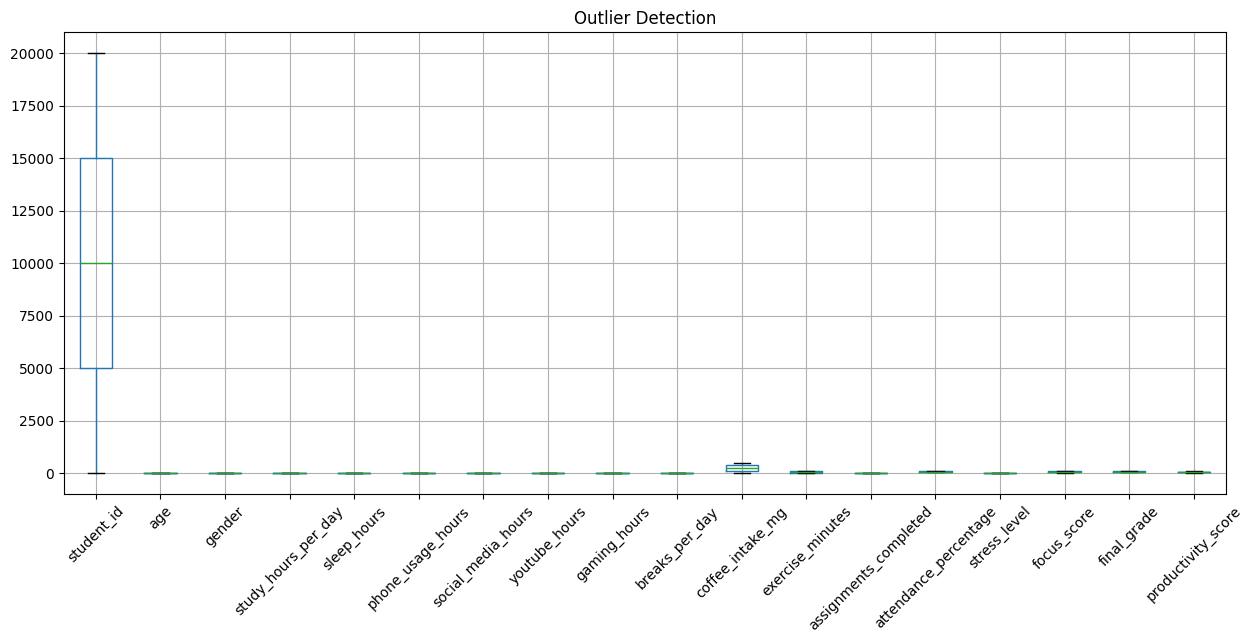

In [41]:
plt.figure(figsize=(15,6))
df.boxplot(rot=45)
plt.title("Outlier Detection")
plt.show()

**Pairplot**

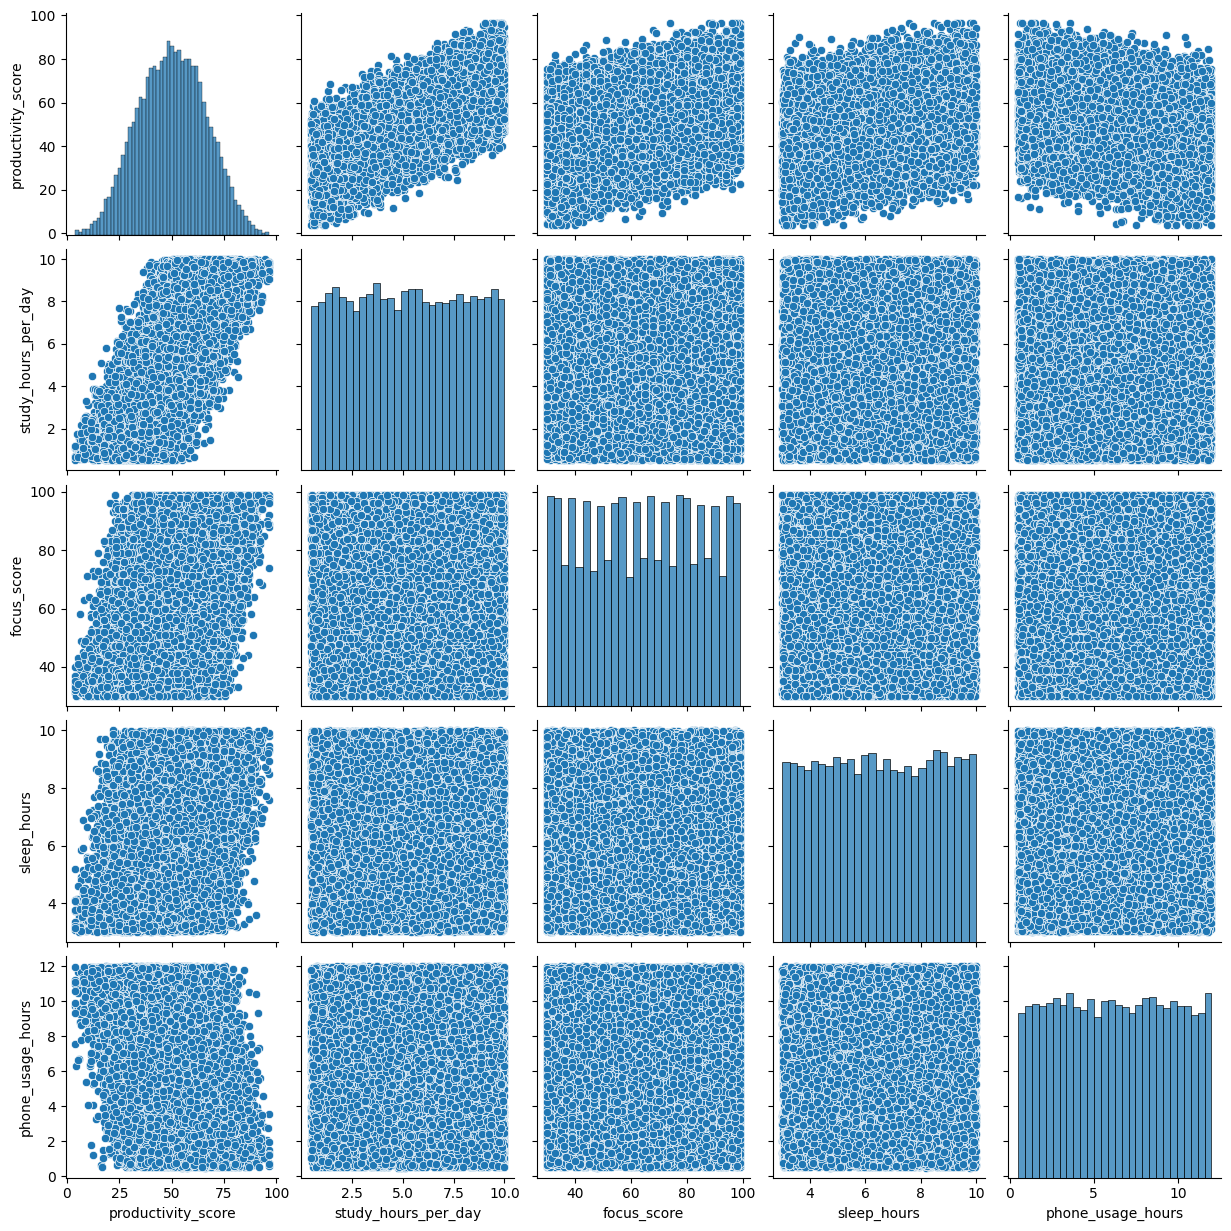

In [42]:
sns.pairplot(df[
[
'productivity_score',
'study_hours_per_day',
'focus_score',
'sleep_hours',
'phone_usage_hours'
]])
plt.show()

**Category Comparison (Gender)**

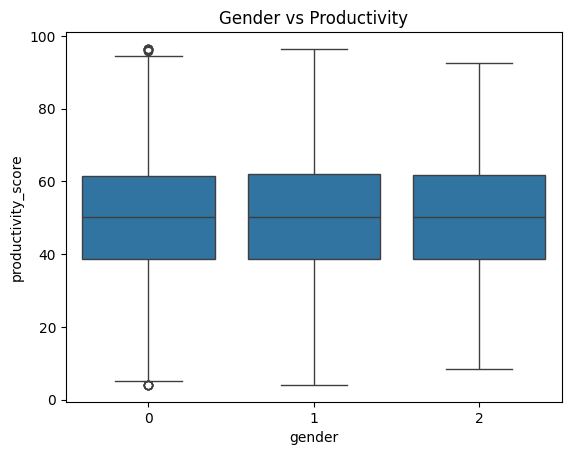

In [43]:
sns.boxplot(
    x='gender',
    y='productivity_score',
    data=df
)
plt.title("Gender vs Productivity")
plt.show()

**Regression Plot**

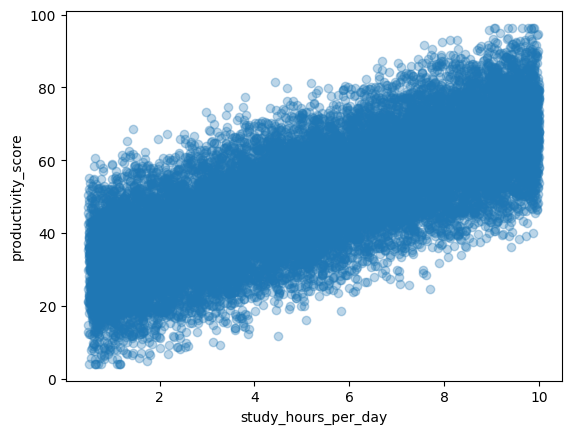

In [44]:
sns.regplot(
    x='study_hours_per_day',
    y='productivity_score',
    data=df,
    scatter_kws={'alpha':0.3}
)
plt.show()

**Bin Study Hours**

In [45]:
df.groupby(pd.cut(df['study_hours_per_day'],5))['productivity_score'].mean()

study_hours_per_day
(0.49, 2.4]    33.852607
(2.4, 4.3]     42.029853
(4.3, 6.2]     49.994388
(6.2, 8.1]     58.759451
(8.1, 10.0]    66.367361
Name: productivity_score, dtype: float64

# Conclusion

The exploratory data analysis shows that student productivity is strongly influenced by study habits and lifestyle factors. Study hours have a positive impact on productivity, while phone usage and stress levels negatively affect it. Sleep and focus also contribute positively. The dataset shows meaningful relationships between features and the target variable, with some presence of outliers. Overall, the data is suitable for building predictive models.